# Chapter 5: Analysis and Findings


In [ ]:
# ============================================================
# Figure output configuration
# ============================================================
# All figures are written here as vector PDFs (resolution-independent).
# After running the notebook in Databricks, download this folder and copy
# the PDFs into the thesis `figures_new/` directory. Figure file names are
# fixed (figure_5_X.pdf) to match the \includegraphics references in the
# thesis source, so do not rename them.
import os

# >>> Change this to where you want the images saved <<<
FIG_DIR = "figures_new"

os.makedirs(FIG_DIR, exist_ok=True)


def save_fig(fig, name, keep_subplot_titles=False):
    """Save `fig` as a vector PDF in FIG_DIR with its title(s) removed.

    Figure titles are dropped because the thesis supplies a caption in LaTeX.
    For multi-panel figures pass keep_subplot_titles=True to retain the
    individual panel titles while still dropping the overall figure title.
    """
    # Drop the overall figure title (suptitle), if any.
    if getattr(fig, "_suptitle", None) is not None:
        fig._suptitle.set_visible(False)
    # Drop per-axis titles unless they are meaningful panel labels.
    if not keep_subplot_titles:
        for ax in fig.axes:
            ax.title.set_visible(False)
    fig.savefig(
        os.path.join(FIG_DIR, f"{name}.pdf"),
        format="pdf",
        bbox_inches="tight",
    )

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "serif"


def q(sql: str) -> pd.DataFrame:
    return spark.sql(sql).toPandas()

MIN_DISPOSED = 50

# ---- Technology Center color scheme (shared across figures) ----
# Art units (~800) are too granular to color individually, so charts are
# colored by the ~15 Technology Centers (art_unit // 100 * 100).
# Official USPTO Technology Center names.
TC_NAMES = {
    1600: "Biotechnology and Organic Chemistry",
    1700: "Chemical and Materials Engineering",
    2100: "Computer Architecture and Software",
    2400: "Networking, Multiplexing, Cable, and Cybersecurity",
    2600: "Communications",
    2800: "Semiconductors/Memory, Circuits/Measuring and Testing, Optics/Photocopying, Printing/Measuring and Testing",
    2900: "Design",
    3600: "Transportation, Construction, Electronic Commerce, Agriculture, National Security and License and Review",
    3700: "Mechanical Engineering, Manufacturing, Gaming, and Medical Devices/Processes",
}
# Shortened names used in chart legends (the full names are too long to fit).
TC_SHORT = {
    1600: "Biotech & Organic Chemistry",
    1700: "Chemical & Materials Eng.",
    2100: "Computer Arch. & Software",
    2400: "Networking & Cybersecurity",
    2600: "Communications",
    2800: "Semiconductors, Circuits & Optics",
    2900: "Design",
    3600: "Transport, Construction & E-Commerce",
    3700: "Mech. Eng. & Manufacturing",
}
TC_COLORS = {
    1600: "#4C78A8", 1700: "#54A24B", 2100: "#F58518", 2400: "#E45756",
    2600: "#72B7B2", 2800: "#B279A2", 2900: "#EECA3B", 3600: "#FF9DA6", 3700: "#9D755D",
}

def tc_of(art_unit) -> int:
    return int(int(art_unit) // 100 * 100)

def tc_label(tc) -> str:
    name = TC_SHORT.get(int(tc), TC_NAMES.get(int(tc), ""))
    return f"TC {int(tc)} - {name}".rstrip(" -")

def tc_color(tc) -> str:
    return TC_COLORS.get(int(tc), "#9E9E9E")

## Section 5.2.1 - Dataset Scale and Temporal Coverage

In [0]:
sql_scale_summary = f"""
WITH disposition_normalized AS (
  SELECT
    a.app_id,
    a.filing_date,
    REGEXP_REPLACE(UPPER(TRIM(COALESCE(a.application_status_desc, ''))), '\\s+', ' ') AS status_norm,
    SUM(CASE WHEN e.event_code = 'CTFR' THEN 1 ELSE 0 END) AS final_rejection_events
  FROM {TBL_APPLICATIONS} a
  LEFT JOIN {TBL_EVENTS} e
    ON e.app_id = a.app_id
    AND e.event_code = 'CTFR'
  GROUP BY a.app_id, a.filing_date, a.application_status_desc
),
classified AS (
  SELECT
    app_id,
    filing_date,
    CASE
      WHEN status_norm IN (
        'PATENTED CASE',
        'PATENT EXPIRED DUE TO NONPAYMENT OF MAINTENANCE FEES UNDER 37 CFR 1.362',
        'ABANDONED -- FAILURE TO PAY ISSUE FEE',
        'NOTICE OF ALLOWANCE MAILED -- APPLICATION RECEIVED IN OFFICE OF PUBLICATIONS',
        'ALLOWED -- NOTICE OF ALLOWANCE NOT YET MAILED'
      ) THEN 'allowed'
      WHEN status_norm IN (
        'FINAL REJECTION MAILED',
        'ABANDONED -- AFTER EXAMINER''S ANSWER OR BOARD OF APPEALS DECISION',
        'FINAL REJECTION COUNTED, NOT YET MAILED'
      ) THEN 'rejected'
      WHEN status_norm = 'ABANDONED -- FAILURE TO RESPOND TO AN OFFICE ACTION' THEN
        CASE WHEN COALESCE(final_rejection_events, 0) > 0 THEN 'rejected' ELSE 'excluded' END
      ELSE 'excluded'
    END AS disposition
  FROM disposition_normalized
)
SELECT
  COUNT(*)                                         AS total_applications,
  COUNT(DISTINCT CASE WHEN filing_date IS NOT NULL THEN app_id END) AS apps_with_filing_date,
  MIN(filing_date)                                 AS earliest_filing_date,
  MAX(filing_date)                                 AS latest_filing_date,
  SUM(CASE WHEN disposition = 'allowed'  THEN 1 ELSE 0 END) AS allowed_count,
  SUM(CASE WHEN disposition = 'rejected' THEN 1 ELSE 0 END) AS rejected_count,
  SUM(CASE WHEN disposition = 'excluded' THEN 1 ELSE 0 END) AS pending_or_excluded_count
FROM classified
"""

scale_summary = q(sql_scale_summary)
scale_summary

,total_applications,apps_with_filing_date,earliest_filing_date,latest_filing_date,allowed_count,rejected_count,pending_or_excluded_count
0,12689020,12567643,2001-01-01,2026-02-03,6648526,63364,5977130


In [0]:
sql_event_counts = f"""
SELECT
  COUNT(*)                                                    AS total_events,
  SUM(CASE WHEN event_code IN ('CTNF','CTFR') THEN 1 ELSE 0 END) AS office_actions,
  SUM(CASE WHEN event_code = 'RCEX' THEN 1 ELSE 0 END)        AS rce_events,
  SUM(CASE WHEN event_code = 'WPIR' THEN 1 ELSE 0 END)        AS issuance_events,
  SUM(CASE WHEN event_code = 'N/AP' THEN 1 ELSE 0 END)        AS notice_of_appeal_events
FROM {TBL_EVENTS}
"""

event_counts = q(sql_event_counts)
event_counts

,total_events,office_actions,rce_events,issuance_events,notice_of_appeal_events
0,478639110,15182307,3033731,6650819,488175


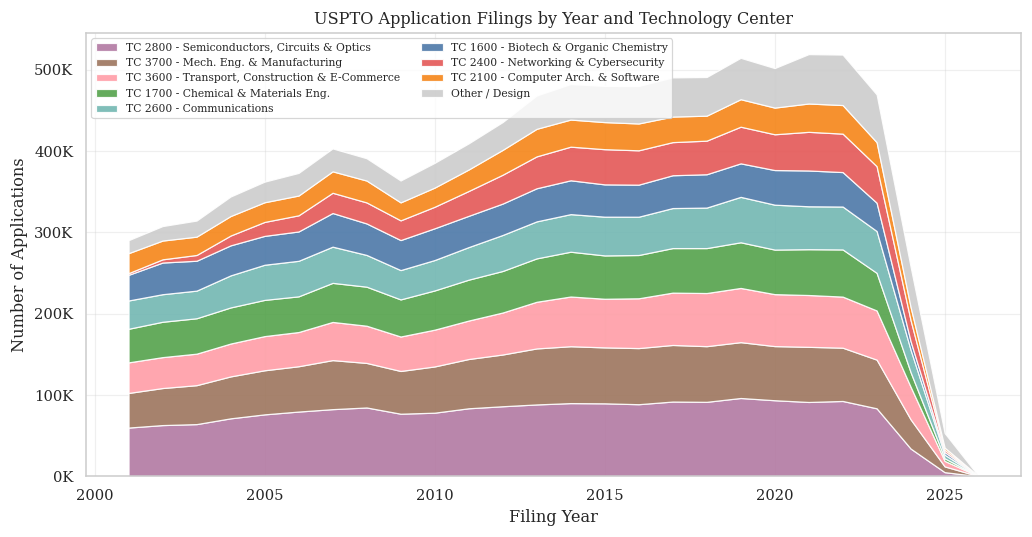

In [0]:
sql_filings_by_year = f"""
SELECT
  YEAR(filing_date) AS filing_year,
  CAST(FLOOR(CAST(group_art_unit AS INT)/100)*100 AS INT) AS tech_center,
  COUNT(*) AS application_count
FROM {TBL_APPLICATIONS}
WHERE filing_date IS NOT NULL
  AND YEAR(filing_date) BETWEEN 1990 AND YEAR(CURRENT_DATE())
  AND group_art_unit RLIKE '^[0-9]+$'
GROUP BY YEAR(filing_date), FLOOR(CAST(group_art_unit AS INT)/100)*100
ORDER BY filing_year
"""

filings_by_year = q(sql_filings_by_year)

pivot = filings_by_year.pivot(index="filing_year", columns="tech_center",
                              values="application_count").fillna(0)
# Keep the largest Technology Centers individually; lump the rest into "Other".
top_tcs = pivot.sum().sort_values(ascending=False).head(8).index.tolist()
other = [c for c in pivot.columns if c not in top_tcs]
plot_df = pivot[top_tcs].copy()
if other:
    plot_df["Other"] = pivot[other].sum(axis=1)

stack_cols = top_tcs + (["Other"] if other else [])
colors = [tc_color(t) for t in top_tcs] + (["#cccccc"] if other else [])
labels = [tc_label(t) for t in top_tcs] + (["Other / Design"] if other else [])

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.stackplot(plot_df.index,
             [plot_df[c].values for c in stack_cols],
             labels=labels, colors=colors, alpha=0.9)
ax.set_xlabel("Filing Year")
ax.set_ylabel("Number of Applications")
ax.set_title("USPTO Application Filings by Year and Technology Center")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.legend(loc="upper left", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_1")
plt.show()

## Section 5.2.2 - Examiner Population

In [0]:
sql_examiner_counts = f"""
WITH cleaned_apps AS (
  SELECT
    TRIM(a.examiner_name) AS examiner_name,
    YEAR(a.filing_date) AS filing_year
  FROM {TBL_APPLICATIONS} a
  WHERE a.examiner_name IS NOT NULL
    AND TRIM(a.examiner_name) != ''
    AND UPPER(TRIM(a.examiner_name)) != 'UNKNOWN'
    AND a.filing_date IS NOT NULL
)
SELECT
  COUNT(DISTINCT examiner_name) AS total_examiners_all_time,
  COUNT(DISTINCT CASE WHEN filing_year >= YEAR(CURRENT_DATE()) - 5  THEN examiner_name END) AS active_last_5y,
  COUNT(DISTINCT CASE WHEN filing_year >= YEAR(CURRENT_DATE()) - 10 THEN examiner_name END) AS active_last_10y
FROM cleaned_apps
"""

examiner_counts = q(sql_examiner_counts)
examiner_counts

,total_examiners_all_time,active_last_5y,active_last_10y
0,17747,11448,13185


In [0]:
sql_apps_per_examiner_stats = f"""
WITH apps_per_examiner AS (
  SELECT
    TRIM(a.examiner_name) AS examiner_name,
    COUNT(DISTINCT a.app_id) AS application_count
  FROM {TBL_APPLICATIONS} a
  WHERE a.examiner_name IS NOT NULL
    AND TRIM(a.examiner_name) != ''
    AND UPPER(TRIM(a.examiner_name)) != 'UNKNOWN'
    AND a.filing_date IS NOT NULL
  GROUP BY TRIM(a.examiner_name)
)
SELECT
  COUNT(*)                                       AS examiner_count,
  ROUND(AVG(application_count), 1)               AS mean_apps,
  PERCENTILE(application_count, 0.10)            AS p10,
  PERCENTILE(application_count, 0.25)            AS p25,
  PERCENTILE(application_count, 0.50)            AS p50_median,
  PERCENTILE(application_count, 0.75)            AS p75,
  PERCENTILE(application_count, 0.90)            AS p90,
  PERCENTILE(application_count, 0.95)            AS p95,
  PERCENTILE(application_count, 0.99)            AS p99,
  MIN(application_count)                         AS min_apps,
  MAX(application_count)                         AS max_apps
FROM apps_per_examiner
"""

apps_per_examiner_stats = q(sql_apps_per_examiner_stats)
apps_per_examiner_stats

,examiner_count,mean_apps,p10,p25,p50_median,p75,p90,p95,p99,min_apps,max_apps
0,17747,569.1,6.0,53.0,297.0,815.0,1358.0,1768.0,2630.54,1,358910


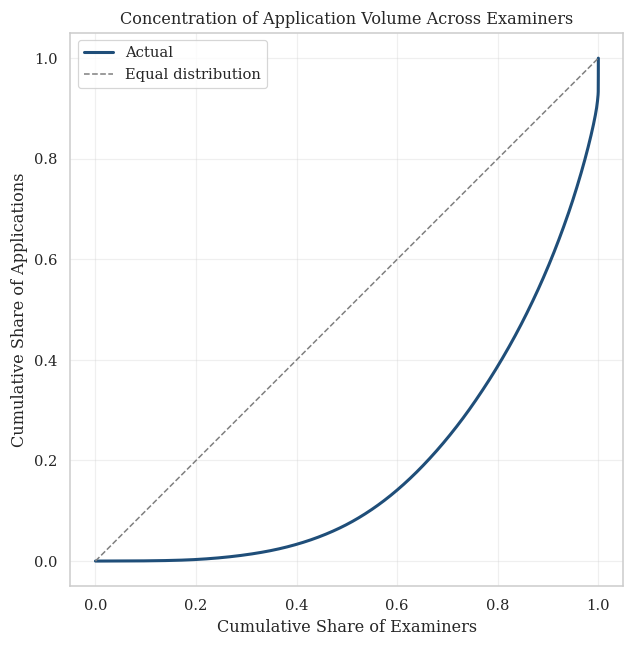

In [0]:
sql_examiner_distribution = f"""
SELECT
  TRIM(a.examiner_name) AS examiner_name,
  COUNT(DISTINCT a.app_id) AS application_count
FROM {TBL_APPLICATIONS} a
WHERE a.examiner_name IS NOT NULL
  AND TRIM(a.examiner_name) != ''
  AND UPPER(TRIM(a.examiner_name)) != 'UNKNOWN'
  AND a.filing_date IS NOT NULL
GROUP BY TRIM(a.examiner_name)
"""

examiner_distribution = q(sql_examiner_distribution)

counts = np.sort(examiner_distribution["application_count"].values)
cum_examiners = np.arange(1, len(counts) + 1) / len(counts)
cum_apps = np.cumsum(counts) / counts.sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(cum_examiners, cum_apps, color="#1f4e79", linewidth=2, label="Actual")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Equal distribution")
ax.set_xlabel("Cumulative Share of Examiners")
ax.set_ylabel("Cumulative Share of Applications")
ax.set_title("Concentration of Application Volume Across Examiners")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
save_fig(fig, "figure_5_3")
plt.show()

## Section 5.2.3 - Art Unit and Technology Center Structure

In [0]:
sql_au_counts = f"""
SELECT
  COUNT(DISTINCT group_art_unit) AS total_art_units,
  COUNT(DISTINCT FLOOR(CAST(group_art_unit AS INT)/100)*100) AS total_tech_centers
FROM {TBL_APPLICATIONS}
WHERE group_art_unit IS NOT NULL
  AND filing_date IS NOT NULL
  AND group_art_unit RLIKE '^[0-9]+$'
"""

au_counts = q(sql_au_counts)
au_counts

,total_art_units,total_tech_centers
0,808,15


    tech_center  application_count
0          2800            1940314
1          3700            1432012
2          3600            1251462
3          1700            1169744
4          2600            1055631
5          1600             910336
6          2400             735132
7          2100             679085
8          2900             675318
9          3900             247820
10         4100               3368
11         6200               2867
12         2200                 17
13         5300                  3
14         2700                  3


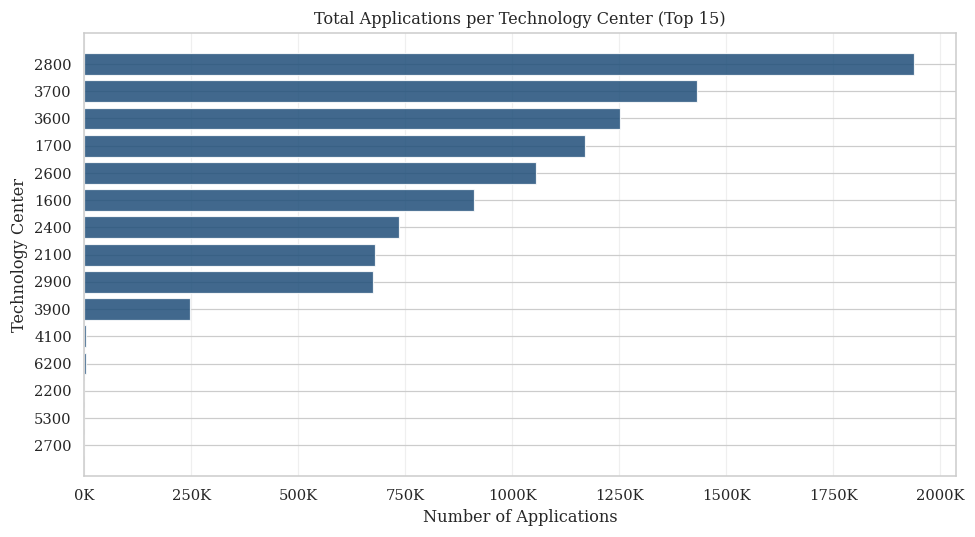

In [0]:
sql_tc_counts = f"""
SELECT
  CAST(FLOOR(CAST(group_art_unit AS INT)/100)*100 AS INT) AS tech_center,
  COUNT(DISTINCT app_id) AS application_count
FROM {TBL_APPLICATIONS}
WHERE group_art_unit IS NOT NULL
  AND filing_date IS NOT NULL
  AND group_art_unit RLIKE '^[0-9]+$'
GROUP BY FLOOR(CAST(group_art_unit AS INT)/100)*100
ORDER BY application_count DESC
"""

tc_counts = q(sql_tc_counts)
print(tc_counts.head(20))

fig, ax = plt.subplots(figsize=(9, 5))
top = tc_counts.head(15).iloc[::-1]
ax.barh(top["tech_center"].astype(str), top["application_count"],
        color="#1f4e79", alpha=0.85)
ax.set_xlabel("Number of Applications")
ax.set_ylabel("Technology Center")
ax.set_title("Total Applications per Technology Center (Top 15)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
save_fig(fig, "figure_5_4")
plt.show()

Total art units: 808
count       808.000000
mean      12503.851485
std       12753.242389
min           1.000000
25%        3873.500000
50%       10064.000000
75%       17324.000000
max      140462.000000
Name: application_count, dtype: float64


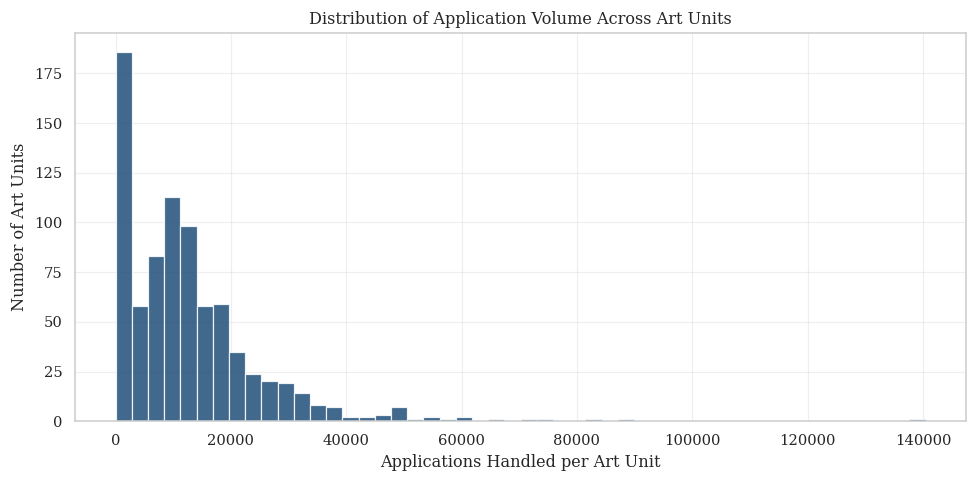

In [0]:
sql_au_dist = f"""
SELECT
  group_art_unit,
  COUNT(DISTINCT app_id) AS application_count
FROM {TBL_APPLICATIONS}
WHERE group_art_unit IS NOT NULL
  AND filing_date IS NOT NULL
  AND group_art_unit RLIKE '^[0-9]+$'
GROUP BY group_art_unit
"""

au_dist = q(sql_au_dist)
print(f"Total art units: {len(au_dist):,}")
print(au_dist["application_count"].describe())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(au_dist["application_count"], bins=50,
        color="#1f4e79", edgecolor="white", alpha=0.85)
ax.set_xlabel("Applications Handled per Art Unit")
ax.set_ylabel("Number of Art Units")
ax.set_title("Distribution of Application Volume Across Art Units")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_5")
plt.show()

## Section 5.2.4 - Filing Volume by Application Type

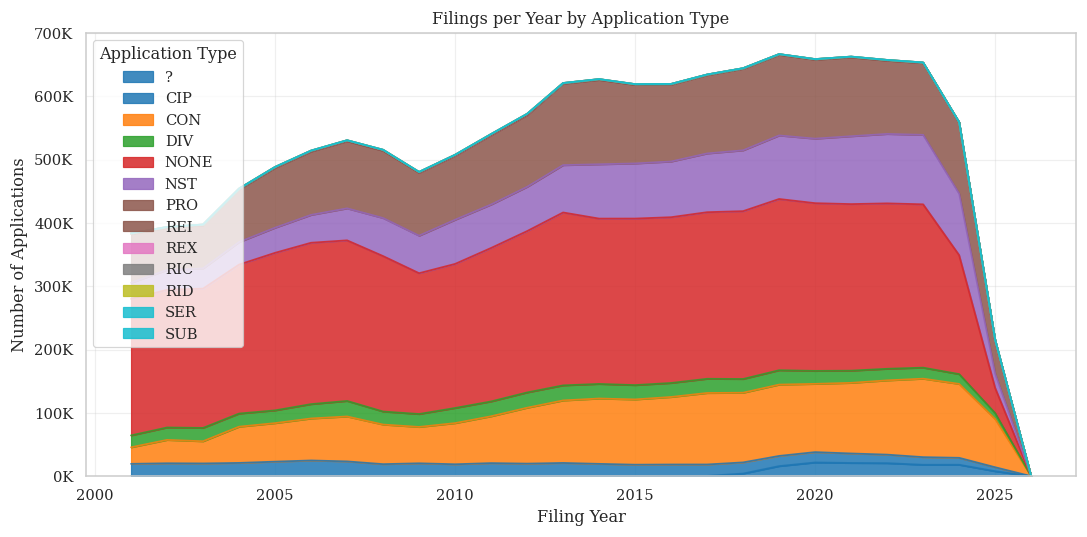

In [0]:
sql_filings_by_type = f"""
SELECT
  YEAR(a.filing_date) AS filing_year,
  COALESCE(act.application_type, 'NONE') AS application_type,
  COUNT(*) AS application_count
FROM {TBL_APPLICATIONS} a
LEFT JOIN {TBL_APPLICATION_CONTINUITY} act
  ON a.app_id = act.app_id
WHERE a.filing_date IS NOT NULL
  AND YEAR(a.filing_date) BETWEEN 2001 AND YEAR(CURRENT_DATE())
GROUP BY YEAR(a.filing_date), COALESCE(act.application_type, 'NONE')
ORDER BY filing_year, application_type
"""

filings_by_type = q(sql_filings_by_type)
pivot = filings_by_type.pivot(index="filing_year", columns="application_type",
                               values="application_count").fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot.area(ax=ax, alpha=0.85, colormap="tab10")
ax.set_xlabel("Filing Year")
ax.set_ylabel("Number of Applications")
ax.set_title("Filings per Year by Application Type")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.legend(title="Application Type", loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_6")
plt.show()

## Section 5.3 - Examiner Allowance Rate Distributions

Examiners after volume filter: 12,319
count    12319.000000
mean         0.792797
std          0.173629
min          0.000000
25%          0.702731
50%          0.839506
75%          0.923573
max          1.000000
Name: allowance_rate, dtype: float64


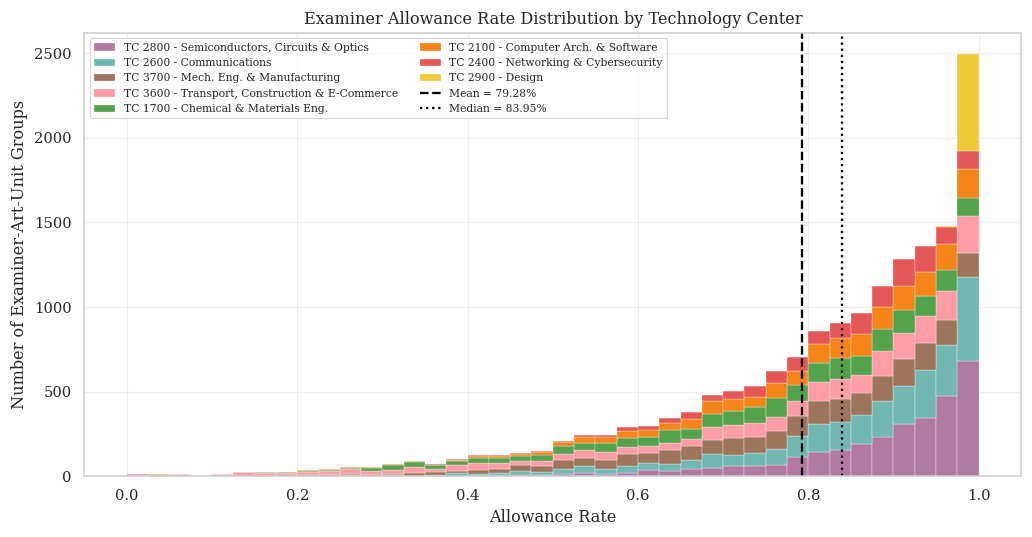

In [0]:
sql_examiner_rates = f"""
SELECT
  examiner_name,
  SUM(allowed_applications) AS allowed,
  SUM(rejected_applications) AS rejected,
  SUM(total_applications) AS total_apps,
  CASE WHEN SUM(allowed_applications + rejected_applications) > 0
    THEN SUM(allowed_applications)::DOUBLE / SUM(allowed_applications + rejected_applications)
    ELSE NULL END AS allowance_rate
FROM {TBL_EXAMINER_SUMMARY}
WHERE time_period = 'all'
GROUP BY examiner_name
HAVING SUM(allowed_applications + rejected_applications) >= {MIN_DISPOSED}
"""

examiner_rates = q(sql_examiner_rates)
print(f"Examiners after volume filter: {len(examiner_rates):,}")
print(examiner_rates["allowance_rate"].describe())

# Per-(examiner, art unit) rates so the histogram can be colored by Technology Center
sql_rates_by_tc = f"""
SELECT group_art_unit, examiner_allowance_rate
FROM {TBL_EXAMINER_AU_COMPARISON}
WHERE time_period = 'all'
  AND application_type = 'NONE'
  AND examiner_allowance_rate IS NOT NULL
  AND total_applications >= {MIN_DISPOSED}
  AND group_art_unit RLIKE '^[0-9]+$'
"""
rates_by_tc = q(sql_rates_by_tc)
rates_by_tc["rate"] = rates_by_tc["examiner_allowance_rate"].astype(float)
rates_by_tc["tech_center"] = rates_by_tc["group_art_unit"].apply(tc_of)

top_tcs = rates_by_tc["tech_center"].value_counts().head(8).index.tolist()
bins = np.linspace(0, 1, 41)
series = [rates_by_tc.loc[rates_by_tc["tech_center"] == t, "rate"].values for t in top_tcs]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.hist(series, bins=bins, stacked=True,
        color=[tc_color(t) for t in top_tcs],
        label=[tc_label(t) for t in top_tcs],
        edgecolor="white", linewidth=0.2)
ax.axvline(examiner_rates["allowance_rate"].mean(), color="black", linestyle="--",
           linewidth=1.5, label=f"Mean = {examiner_rates['allowance_rate'].mean():.2%}")
ax.axvline(examiner_rates["allowance_rate"].median(), color="black", linestyle=":",
           linewidth=1.5, label=f"Median = {examiner_rates['allowance_rate'].median():.2%}")
ax.set_xlabel("Allowance Rate")
ax.set_ylabel("Number of Examiner-Art-Unit Groups")
ax.set_title("Examiner Allowance Rate Distribution by Technology Center")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_7")
plt.show()

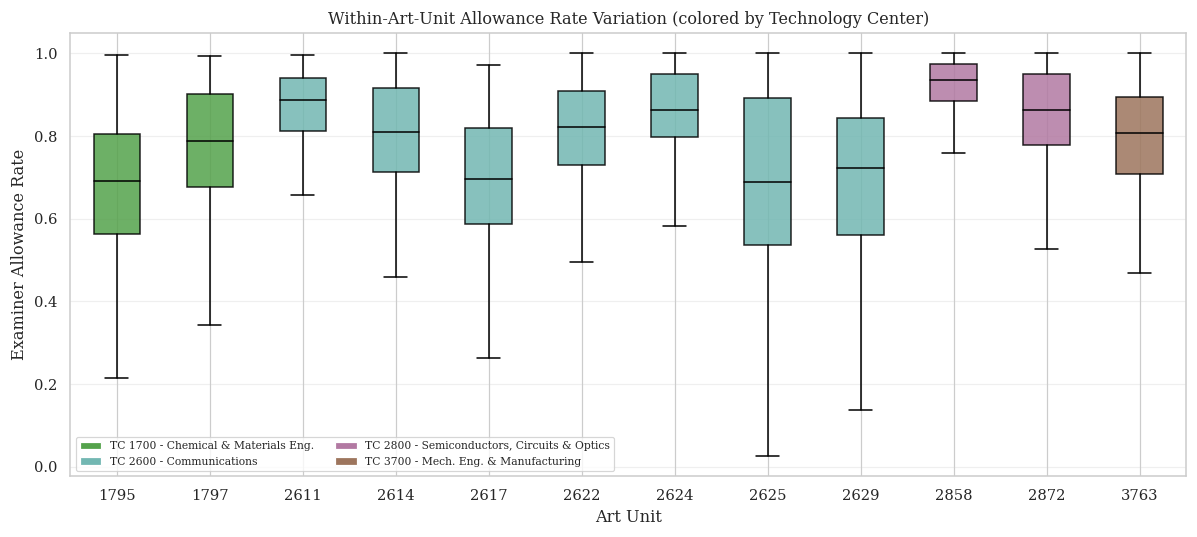

In [0]:
sql_within_au = f"""
SELECT
  examiner_name,
  group_art_unit,
  examiner_allowance_rate,
  total_applications
FROM {TBL_EXAMINER_AU_COMPARISON}
WHERE time_period = 'all'
  AND application_type = 'NONE'
  AND examiner_allowance_rate IS NOT NULL
  AND total_applications >= {MIN_DISPOSED}
  AND group_art_unit RLIKE '^[0-9]+$'
"""

within_au = q(sql_within_au)
within_au["examiner_allowance_rate"] = within_au["examiner_allowance_rate"].astype(float)

from matplotlib.patches import Patch

au_sizes = within_au.groupby("group_art_unit").size().sort_values(ascending=False)
sample_aus = au_sizes.head(12).index.tolist()
# Order art units by Technology Center so same-TC units sit together
sample_aus = sorted(sample_aus, key=lambda a: (tc_of(a), int(a)))
sample = within_au[within_au["group_art_unit"].isin(sample_aus)].copy()

fig, ax = plt.subplots(figsize=(11, 5))
data = [sample.loc[sample["group_art_unit"] == au, "examiner_allowance_rate"].values
        for au in sample_aus]
tcs = [tc_of(au) for au in sample_aus]

bp = ax.boxplot(data, patch_artist=True, labels=[str(a) for a in sample_aus],
                medianprops=dict(color="black"), showfliers=False)
for patch, tc in zip(bp["boxes"], tcs):
    patch.set_facecolor(tc_color(tc))
    patch.set_alpha(0.85)

present_tcs = sorted(set(tcs))
ax.legend(handles=[Patch(facecolor=tc_color(t), label=tc_label(t)) for t in present_tcs],
          fontsize=7, ncol=2, loc="lower left")
ax.set_xlabel("Art Unit")
ax.set_ylabel("Examiner Allowance Rate")
ax.set_title("Within-Art-Unit Allowance Rate Variation (colored by Technology Center)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
save_fig(fig, "figure_5_8")
plt.show()

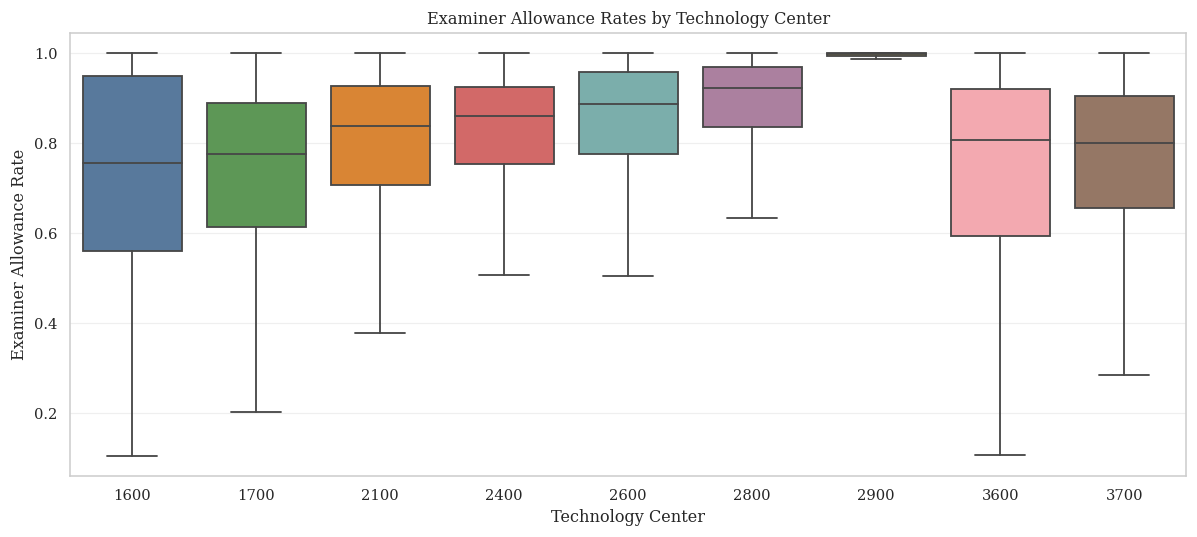

In [0]:
# Keep only numeric art units (drops non-numeric codes such as 'OPT'),
# then map each to its parent Technology Center.
num_au = within_au[within_au["group_art_unit"].astype(str).str.match(r"^\d+$")].copy()
num_au["tech_center"] = num_au["group_art_unit"].apply(tc_of)

tc_examiner_rates = num_au.groupby("tech_center").filter(lambda x: len(x) >= 20)

order = sorted(tc_examiner_rates["tech_center"].unique())
palette = [tc_color(t) for t in order]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=tc_examiner_rates,
            x="tech_center", y="examiner_allowance_rate",
            order=order, hue="tech_center", hue_order=order,
            palette=palette, legend=False, showfliers=False, ax=ax)
ax.set_xlabel("Technology Center")
ax.set_ylabel("Examiner Allowance Rate")
ax.set_title("Examiner Allowance Rates by Technology Center")
ax.set_xticklabels([str(t) for t in order], rotation=0)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
save_fig(fig, "figure_5_9")
plt.show()

## Section 5.4 - Office Action Patterns

count    13488.000000
mean         1.778891
std          0.676756
min          0.000000
25%          1.330017
50%          1.751394
75%          2.200085
max          5.077749
Name: avg_office_actions, dtype: float64


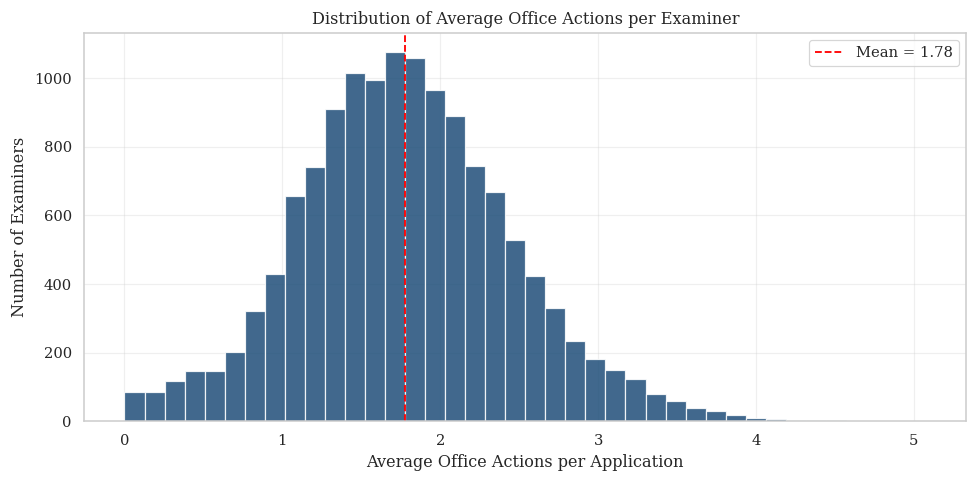

In [0]:
sql_examiner_oas = f"""
SELECT
  examiner_name,
  AVG(overall_avg_office_actions) AS avg_office_actions,
  SUM(total_applications) AS total_apps
FROM {TBL_EXAMINER_SUMMARY}
WHERE time_period = 'all'
  AND overall_avg_office_actions IS NOT NULL
GROUP BY examiner_name
HAVING SUM(total_applications) >= {MIN_DISPOSED}
"""

examiner_oas = q(sql_examiner_oas)
print(examiner_oas["avg_office_actions"].describe())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(examiner_oas["avg_office_actions"], bins=40,
        color="#1f4e79", edgecolor="white", alpha=0.85)
ax.axvline(examiner_oas["avg_office_actions"].mean(), color="red", linestyle="--",
           label=f"Mean = {examiner_oas['avg_office_actions'].mean():.2f}")
ax.set_xlabel("Average Office Actions per Application")
ax.set_ylabel("Number of Examiners")
ax.set_title("Distribution of Average Office Actions per Examiner")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_10")
plt.show()

Examiners with both metrics: 12,319
Pearson correlation: -0.660


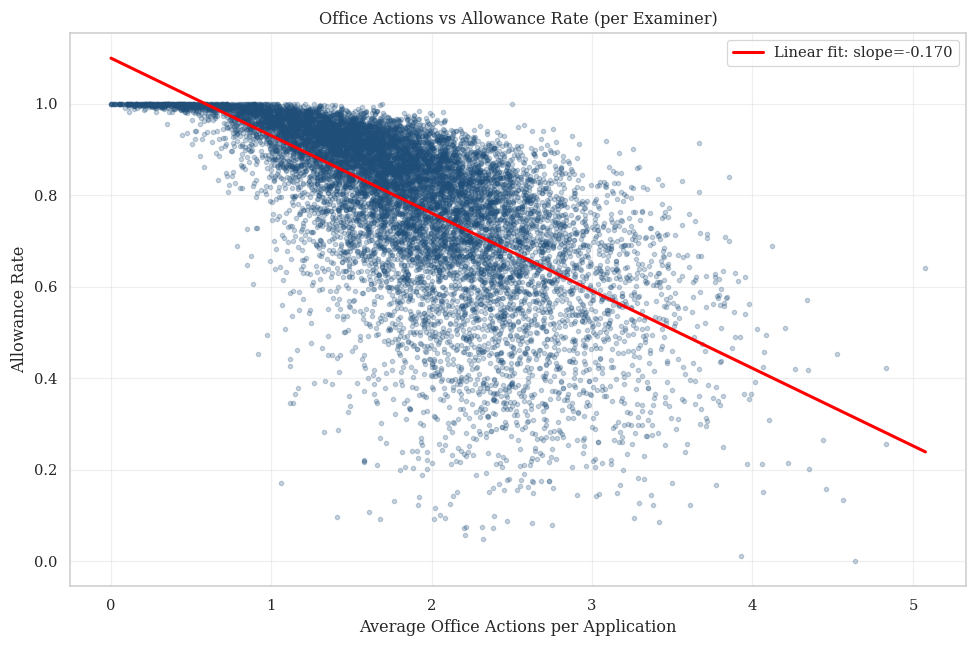

In [0]:
combined = examiner_rates.merge(examiner_oas[["examiner_name", "avg_office_actions"]],
                                  on="examiner_name", how="inner")
print(f"Examiners with both metrics: {len(combined):,}")
print(f"Pearson correlation: {combined['avg_office_actions'].corr(combined['allowance_rate']):.3f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(combined["avg_office_actions"], combined["allowance_rate"],
           alpha=0.25, s=8, color="#1f4e79")

m, b = np.polyfit(combined["avg_office_actions"], combined["allowance_rate"], 1)
xs = np.linspace(combined["avg_office_actions"].min(), combined["avg_office_actions"].max(), 100)
ax.plot(xs, m*xs + b, color="red", linewidth=2, label=f"Linear fit: slope={m:.3f}")

ax.set_xlabel("Average Office Actions per Application")
ax.set_ylabel("Allowance Rate")
ax.set_title("Office Actions vs Allowance Rate (per Examiner)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_11")
plt.show()

In [0]:
sql_examiner_tti = f"""
SELECT
  examiner_name,
  avg_days_to_issuance,
  total_issuances
FROM {TBL_TIME_TO_ISSUANCE}
WHERE time_period = 'all'
  AND avg_days_to_issuance IS NOT NULL
  AND total_issuances >= 30
"""

try:
    examiner_tti = q(sql_examiner_tti)
    print(examiner_tti["avg_days_to_issuance"].describe())

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(examiner_tti["avg_days_to_issuance"], bins=40,
            color="#1f4e79", edgecolor="white", alpha=0.85)
    ax.axvline(examiner_tti["avg_days_to_issuance"].mean(), color="red", linestyle="--",
               label=f"Mean = {examiner_tti['avg_days_to_issuance'].mean():.0f} days")
    ax.set_xlabel("Average Days to Issuance")
    ax.set_ylabel("Number of Examiners")
    ax.set_title("Distribution of Average Time to Issuance per Examiner")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig, "figure_5_12")
    plt.show()
except Exception as e:
    print(f"The time-to-issuance table may have different columns. Error: {e}")

## Section 5.5 - RCE Usage and Outcomes

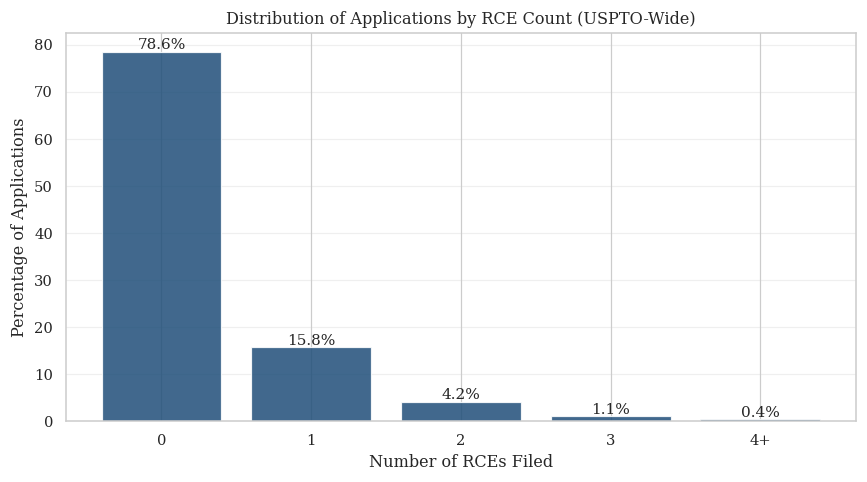

In [0]:
sql_rce_dist = f"""
SELECT
  SUM(apps_with_0_rce) AS bucket_0,
  SUM(apps_with_1_rce) AS bucket_1,
  SUM(apps_with_2_rce) AS bucket_2,
  SUM(apps_with_3_rce) AS bucket_3,
  SUM(apps_with_4plus_rce) AS bucket_4plus,
  SUM(total_applications) AS total
FROM {TBL_RCE_DISTRIBUTION}
WHERE time_period = 'all'
  AND application_type = 'NONE'
"""

rce_dist = q(sql_rce_dist).iloc[0]
buckets = ["0", "1", "2", "3", "4+"]
counts = [rce_dist["bucket_0"], rce_dist["bucket_1"], rce_dist["bucket_2"],
          rce_dist["bucket_3"], rce_dist["bucket_4plus"]]
total = rce_dist["total"]
pcts = [c/total*100 for c in counts]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(buckets, pcts, color="#1f4e79", alpha=0.85)
for i, (c, p) in enumerate(zip(counts, pcts)):
    ax.text(i, p + 0.5, f"{p:.1f}%", ha="center", fontsize=10)
ax.set_xlabel("Number of RCEs Filed")
ax.set_ylabel("Percentage of Applications")
ax.set_title("Distribution of Applications by RCE Count (USPTO-Wide)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
save_fig(fig, "figure_5_13")
plt.show()

avg_with_rce       0.78728983
avg_without_rce    0.68741310
n_groups                16408
n_with_rce             809096
n_without_rce         2446356
n_total               3255452
Name: 0, dtype: object

Examiner-art-unit groups: 16,408
Applications WITH RCE:    809,096
Applications WITHOUT RCE: 2,446,356
Total applications:       3,255,452


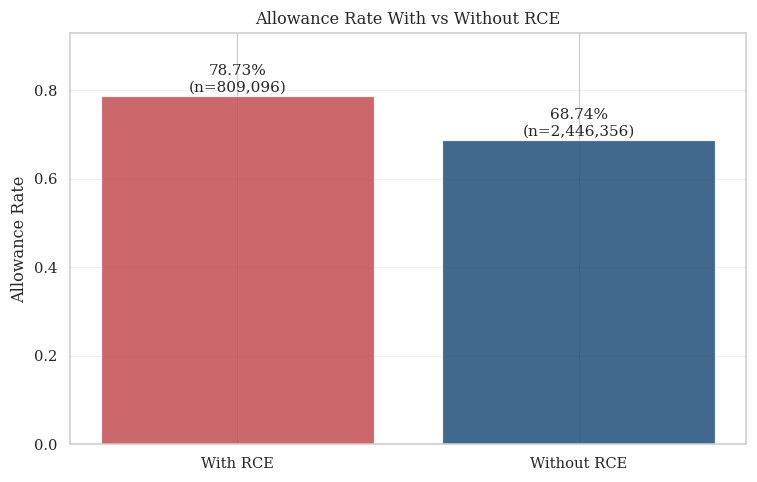

In [0]:
sql_rce_outcomes = f"""
SELECT
  AVG(allowance_rate_with_rce) AS avg_with_rce,
  AVG(allowance_rate_without_rce) AS avg_without_rce,
  COUNT(*) AS n_groups,
  SUM(applications_with_rce) AS n_with_rce,
  SUM(total_applications) - SUM(applications_with_rce) AS n_without_rce,
  SUM(total_applications) AS n_total
FROM {TBL_RCE_STATS}
WHERE time_period = 'all'
  AND application_type = 'NONE'
  AND allowance_rate_with_rce IS NOT NULL
  AND allowance_rate_without_rce IS NOT NULL
  AND total_applications >= {MIN_DISPOSED}
"""

rce_outcomes = q(sql_rce_outcomes).iloc[0]
print(rce_outcomes)
print(f"\nExaminer-art-unit groups: {int(rce_outcomes['n_groups']):,}")
print(f"Applications WITH RCE:    {int(rce_outcomes['n_with_rce']):,}")
print(f"Applications WITHOUT RCE: {int(rce_outcomes['n_without_rce']):,}")
print(f"Total applications:       {int(rce_outcomes['n_total']):,}")

fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["With RCE", "Without RCE"]
values = [float(rce_outcomes["avg_with_rce"]), float(rce_outcomes["avg_without_rce"])]
ns = [int(rce_outcomes["n_with_rce"]), int(rce_outcomes["n_without_rce"])]
ax.bar(labels, values, color=["#c44e52", "#1f4e79"], alpha=0.85)
for i, (v, n) in enumerate(zip(values, ns)):
    ax.text(i, v + 0.01, f"{v:.2%}\n(n={n:,})", ha="center", fontsize=10)
ax.set_ylim(0, max(values) * 1.18)
ax.set_ylabel("Allowance Rate")
ax.set_title("Allowance Rate With vs Without RCE")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
save_fig(fig, "figure_5_14")
plt.show()

## Section 5.6 - Interview Effectiveness

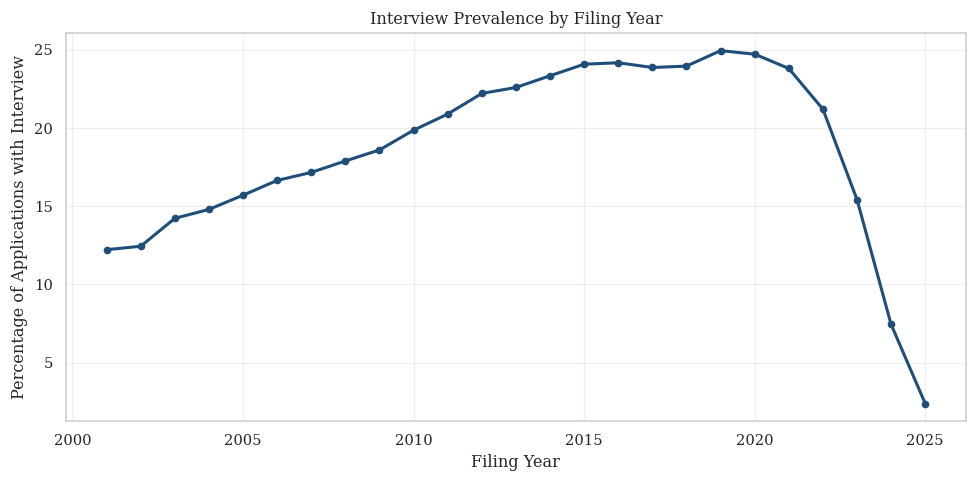

In [0]:
sql_iv_prevalence = f"""
WITH apps_with_iv AS (
  SELECT DISTINCT app_id
  FROM {TBL_EVENTS}
  WHERE event_code IN (
    'EXAC','EXAP','EXAT','EXIE','EXEC','EXEP','EXET','EXIA','EXIN',
    'MEXIA','MEXIE','MEXIN','MEXAC','MEXAP','MEXAT','MEXEC','MEXEP','MEXET',
    'MNCIR','NCIR','FAIA','PRTI','MREXN','MRPWP'
  )
)
SELECT
  YEAR(a.filing_date) AS filing_year,
  COUNT(*) AS total_apps,
  COUNT(awi.app_id) AS apps_with_interview,
  COUNT(awi.app_id) / COUNT(*) AS interview_rate
FROM {TBL_APPLICATIONS} a
LEFT JOIN apps_with_iv awi ON a.app_id = awi.app_id
WHERE a.filing_date IS NOT NULL
  AND YEAR(a.filing_date) BETWEEN 2001 AND YEAR(CURRENT_DATE()) - 1
GROUP BY YEAR(a.filing_date)
ORDER BY filing_year
"""

iv_prevalence = q(sql_iv_prevalence)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(iv_prevalence["filing_year"], iv_prevalence["interview_rate"]*100,
        color="#1f4e79", linewidth=2, marker="o", markersize=4)
ax.set_xlabel("Filing Year")
ax.set_ylabel("Percentage of Applications with Interview")
ax.set_title("Interview Prevalence by Filing Year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_15")
plt.show()

allow_with        0.84894975
allow_without     0.75718787
oa_with             2.547518
oa_without          1.633642
days_with        1247.330768
days_without     1095.809934
n_groups               17041
n_with_iv             878627
n_without_iv         2976481
n_total              3855108
Name: 0, dtype: object

Examiner-art-unit groups:       17,041
Applications WITH interview:    878,627
Applications WITHOUT interview: 2,976,481
Total applications:             3,855,108


/home/spark-51034762-20b1-43ab-aab3-d1/.ipykernel/2846/command-6834946626835394-1941375018:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels([f"With Interview\n(n={n_with:,})",


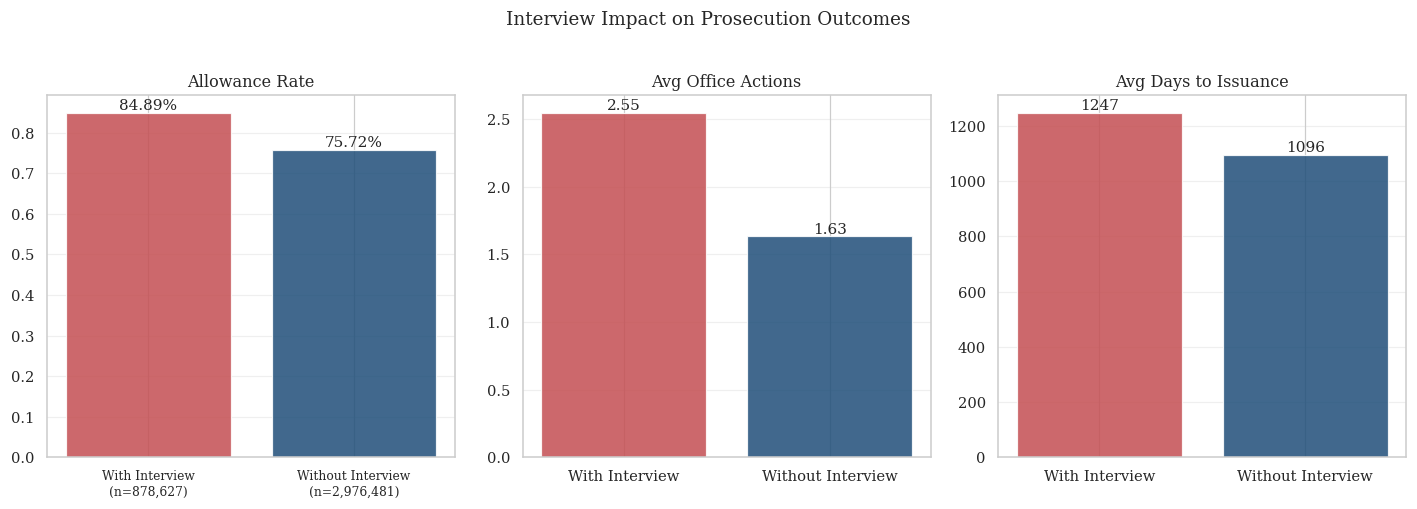

In [0]:
sql_iv_impact = f"""
SELECT
  AVG(allowance_rate_with_interview) AS allow_with,
  AVG(allowance_rate_without_interview) AS allow_without,
  AVG(avg_office_actions_with_interview) AS oa_with,
  AVG(avg_office_actions_without_interview) AS oa_without,
  AVG(avg_days_to_issuance_with_interview) AS days_with,
  AVG(avg_days_to_issuance_without_interview) AS days_without,
  COUNT(*) AS n_groups,
  SUM(applications_with_interview) AS n_with_iv,
  SUM(applications_without_interview) AS n_without_iv,
  SUM(applications_with_interview + applications_without_interview) AS n_total
FROM {TBL_INTERVIEW_STATS}
WHERE time_period = 'all'
  AND application_type = 'NONE'
  AND applications_with_interview + applications_without_interview >= {MIN_DISPOSED}
"""

iv_impact = q(sql_iv_impact).iloc[0]
print(iv_impact)
print(f"\nExaminer-art-unit groups:       {int(iv_impact['n_groups']):,}")
print(f"Applications WITH interview:    {int(iv_impact['n_with_iv']):,}")
print(f"Applications WITHOUT interview: {int(iv_impact['n_without_iv']):,}")
print(f"Total applications:             {int(iv_impact['n_total']):,}")

n_with, n_without = int(iv_impact["n_with_iv"]), int(iv_impact["n_without_iv"])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
metrics = [
    ("Allowance Rate", iv_impact["allow_with"], iv_impact["allow_without"], "{:.2%}"),
    ("Avg Office Actions", iv_impact["oa_with"], iv_impact["oa_without"], "{:.2f}"),
    ("Avg Days to Issuance", iv_impact["days_with"], iv_impact["days_without"], "{:.0f}"),
]
for ax, (title, w, wo, fmt) in zip(axes, metrics):
    ax.bar(["With Interview", "Without Interview"], [w, wo],
           color=["#c44e52", "#1f4e79"], alpha=0.85)
    ax.set_title(title)
    for i, v in enumerate([w, wo]):
        ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")
axes[0].set_xticklabels([f"With Interview\n(n={n_with:,})",
                         f"Without Interview\n(n={n_without:,})"], fontsize=8)
fig.suptitle("Interview Impact on Prosecution Outcomes", fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, "figure_5_16", keep_subplot_titles=True)
plt.show()

Examiners: 11,100


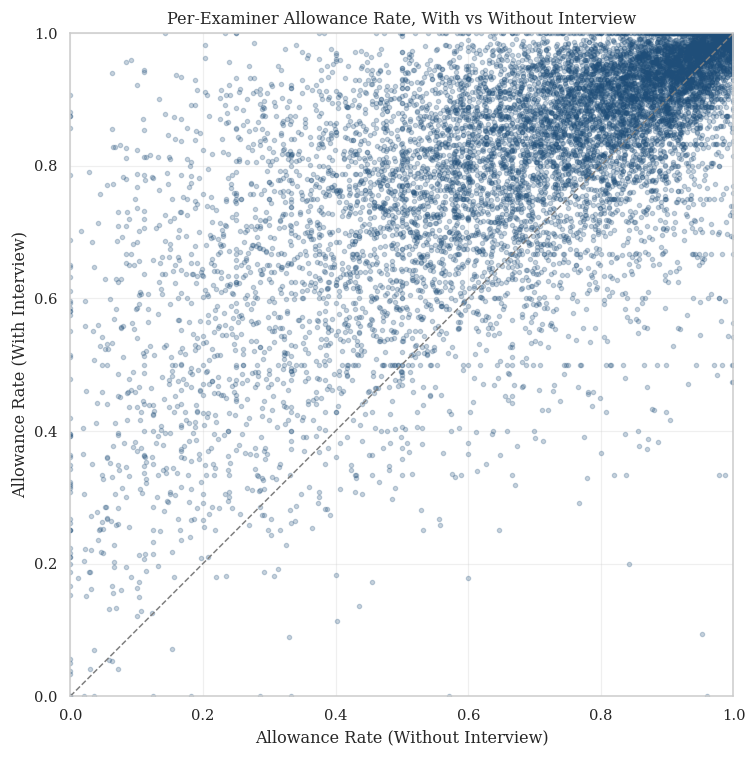

In [0]:
sql_iv_lift = f"""
SELECT
  examiner_name,
  AVG(allowance_rate_with_interview) AS with_iv,
  AVG(allowance_rate_without_interview) AS without_iv,
  SUM(applications_with_interview + applications_without_interview) AS total
FROM {TBL_INTERVIEW_STATS}
WHERE time_period = 'all'
  AND application_type = 'NONE'
  AND allowance_rate_with_interview IS NOT NULL
  AND allowance_rate_without_interview IS NOT NULL
GROUP BY examiner_name
HAVING SUM(applications_with_interview + applications_without_interview) >= {MIN_DISPOSED}
"""

iv_lift = q(sql_iv_lift)
print(f"Examiners: {len(iv_lift):,}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(iv_lift["without_iv"], iv_lift["with_iv"], alpha=0.25, s=8, color="#1f4e79")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Allowance Rate (Without Interview)")
ax.set_ylabel("Allowance Rate (With Interview)")
ax.set_title("Per-Examiner Allowance Rate, With vs Without Interview")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
save_fig(fig, "figure_5_17")
plt.show()

In [0]:
sql_initiator_schema = f"""
SELECT *
FROM {TBL_INTERVIEW_INITIATOR_STATS}
WHERE time_period = 'all'
  AND application_type = 'NONE'
LIMIT 1
"""

try:
    sample = q(sql_initiator_schema)
    print("Columns available:")
    print(list(sample.columns))

    sql_initiator_data = f"""
    SELECT *
    FROM {TBL_INTERVIEW_INITIATOR_STATS}
    WHERE time_period = 'all'
      AND application_type = 'NONE'
    """
    initiator_data = q(sql_initiator_data)
    initiator_data.head()
except Exception as e:
    print(f"Could not query initiator stats: {e}")

Columns available:
['examiner_name', 'group_art_unit', 'application_type', 'time_period', 'applications_examiner_initiated', 'applications_applicant_initiated', 'nokia_applications_examiner_initiated', 'nokia_applications_applicant_initiated', 'allowance_rate_examiner_initiated', 'allowance_rate_applicant_initiated', 'nokia_allowance_rate_examiner_initiated', 'nokia_allowance_rate_applicant_initiated', 'avg_office_actions_examiner_initiated', 'avg_office_actions_applicant_initiated', 'nokia_avg_office_actions_examiner_initiated', 'nokia_avg_office_actions_applicant_initiated', 'avg_days_to_issuance_examiner_initiated', 'avg_days_to_issuance_applicant_initiated', 'nokia_avg_days_to_issuance_examiner_initiated', 'nokia_avg_days_to_issuance_applicant_initiated', 'last_updated']


## Section 5.7 - Appeals, Pre-Appeal Conferences, and PTAB Outcomes

allow_with           0.79198514
allow_without        0.80388421
oa_with                 3.91124
oa_without               1.7995
days_with           1893.827653
days_without        1098.784186
n_groups                  17041
n_with_appeal            153273
n_without_appeal        3701835
Name: 0, dtype: object

Examiner-art-unit groups:    17,041
Applications WITH appeal:    153,273
Applications WITHOUT appeal: 3,701,835


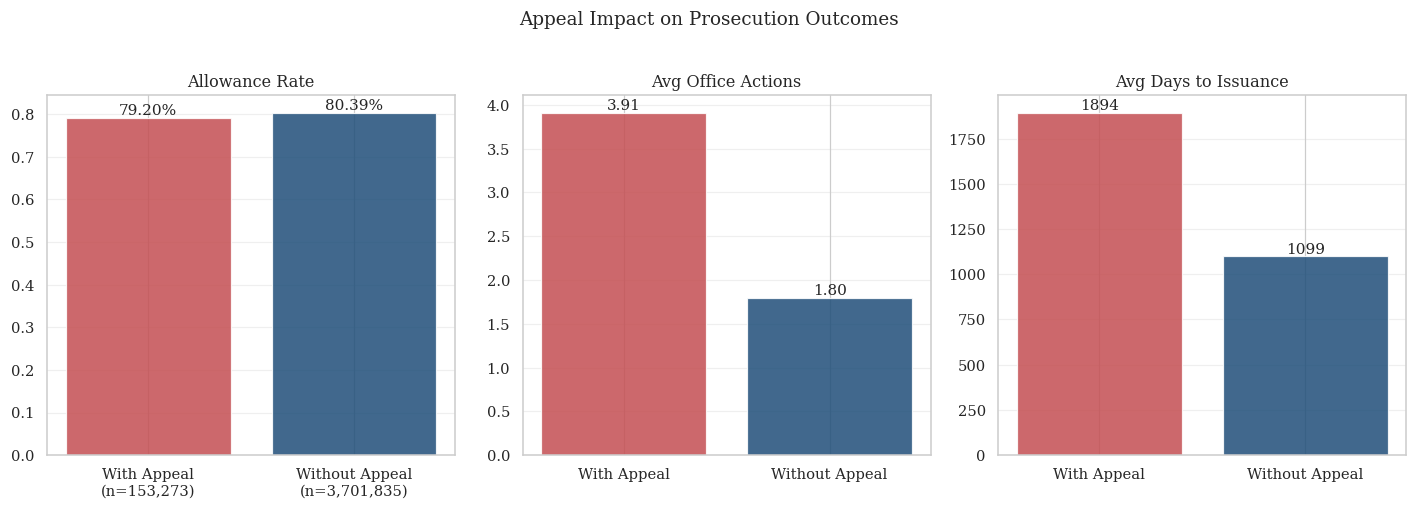

In [0]:
sql_appeal_impact = f"""
SELECT
  AVG(allowance_rate_with_appeal) AS allow_with,
  AVG(allowance_rate_without_appeal) AS allow_without,
  AVG(avg_office_actions_with_appeal) AS oa_with,
  AVG(avg_office_actions_without_appeal) AS oa_without,
  AVG(avg_days_to_issuance_with_appeal) AS days_with,
  AVG(avg_days_to_issuance_without_appeal) AS days_without,
  COUNT(*) AS n_groups,
  SUM(applications_with_appeal) AS n_with_appeal,
  SUM(applications_without_appeal) AS n_without_appeal
FROM {TBL_APPEAL_STATS}
WHERE time_period = 'all'
  AND application_type = 'NONE'
  AND applications_with_appeal + applications_without_appeal >= {MIN_DISPOSED}
"""

appeal_impact = q(sql_appeal_impact).iloc[0]
print(appeal_impact)
print(f"\nExaminer-art-unit groups:    {int(appeal_impact['n_groups']):,}")
print(f"Applications WITH appeal:    {int(appeal_impact['n_with_appeal']):,}")
print(f"Applications WITHOUT appeal: {int(appeal_impact['n_without_appeal']):,}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
metrics = [
    ("Allowance Rate", appeal_impact["allow_with"], appeal_impact["allow_without"], "{:.2%}"),
    ("Avg Office Actions", appeal_impact["oa_with"], appeal_impact["oa_without"], "{:.2f}"),
    ("Avg Days to Issuance", appeal_impact["days_with"], appeal_impact["days_without"], "{:.0f}"),
]
for ax, (title, w, wo, fmt) in zip(axes, metrics):
    ax.bar(["With Appeal", "Without Appeal"], [w, wo],
           color=["#c44e52", "#1f4e79"], alpha=0.85)
    ax.set_title(title)
    for i, v in enumerate([w, wo]):
        if pd.notna(v):
            ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")

# Annotate the allowance panel with application counts (parity with Figs 5.14/5.16)
n_with = int(appeal_impact["n_with_appeal"])
n_without = int(appeal_impact["n_without_appeal"])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels([f"With Appeal\n(n={n_with:,})", f"Without Appeal\n(n={n_without:,})"])

fig.suptitle("Appeal Impact on Prosecution Outcomes", fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, "figure_5_19", keep_subplot_titles=True)
plt.show()

proceed_to_ptab        41893
reopen_prosecution     20924
rejection_withdrawn     4385
request_defective       1130
Name: 0, dtype: int64


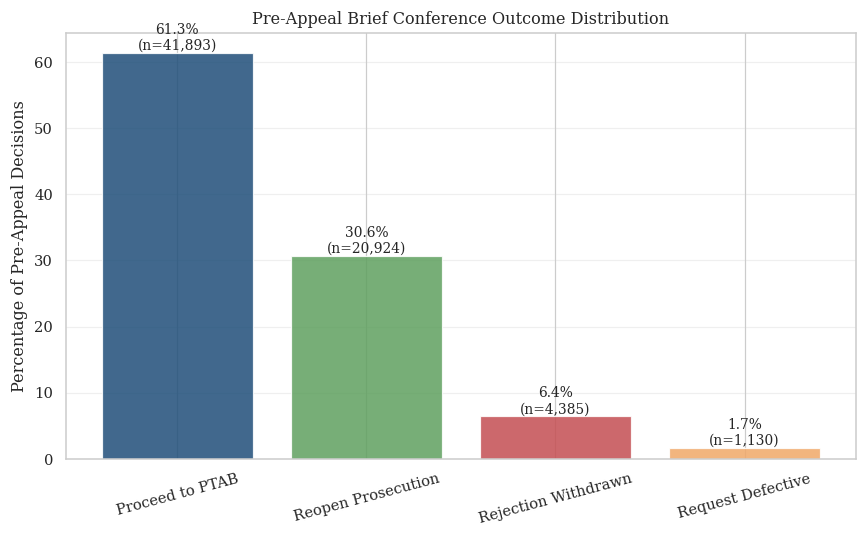

In [0]:
sql_pre_appeal = f"""
SELECT
  SUM(decision_proceed_to_ptab) AS proceed_to_ptab,
  SUM(decision_reopen_prosecution) AS reopen_prosecution,
  SUM(decision_rejection_withdrawn) AS rejection_withdrawn,
  SUM(decision_request_defective) AS request_defective
FROM {TBL_PRE_APPEAL_STATS}
WHERE time_period = 'all'
  AND application_type = 'NONE'
"""

pre_appeal = q(sql_pre_appeal).iloc[0]
print(pre_appeal)

labels = ["Proceed to PTAB", "Reopen Prosecution", "Rejection Withdrawn", "Request Defective"]
values = [pre_appeal["proceed_to_ptab"], pre_appeal["reopen_prosecution"],
          pre_appeal["rejection_withdrawn"], pre_appeal["request_defective"]]
total = sum(values)
pcts = [v/total*100 for v in values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, pcts, color=["#1f4e79", "#5fa05f", "#c44e52", "#f0a868"], alpha=0.85)
for i, (v, p) in enumerate(zip(values, pcts)):
    ax.text(i, p + 0.5, f"{p:.1f}%\n(n={int(v):,})", ha="center", fontsize=9)
ax.set_ylabel("Percentage of Pre-Appeal Decisions")
ax.set_title("Pre-Appeal Brief Conference Outcome Distribution")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=15)
plt.tight_layout()
save_fig(fig, "figure_5_20")
plt.show()

Examiners with >=5 PTAB decisions: 4,615
count    4615.000000
mean        0.676457
std         0.186618
min         0.000000
25%         0.569498
50%         0.680000
75%         0.800000
max         1.000000
Name: affirmance_rate, dtype: float64


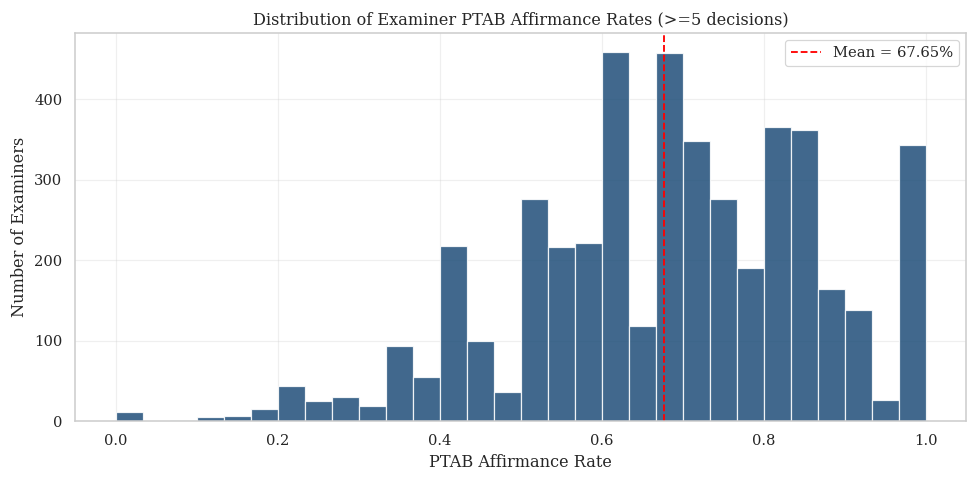

In [0]:
sql_ptab = f"""
SELECT
  examiner_name,
  SUM(total_ptab_decisions) AS total_decisions,
  SUM(examiner_affirmed) AS affirmed,
  SUM(examiner_reversed) AS reversed
FROM {TBL_PTAB_STATS}
WHERE time_period = 'all'
  AND application_type = 'NONE'
GROUP BY examiner_name
HAVING SUM(total_ptab_decisions) >= 5
"""

ptab = q(sql_ptab)
ptab["affirmance_rate"] = ptab["affirmed"] / (ptab["affirmed"] + ptab["reversed"])
print(f"Examiners with >=5 PTAB decisions: {len(ptab):,}")
print(ptab["affirmance_rate"].describe())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(ptab["affirmance_rate"].dropna(), bins=30,
        color="#1f4e79", edgecolor="white", alpha=0.85)
ax.axvline(ptab["affirmance_rate"].mean(), color="red", linestyle="--",
           label=f"Mean = {ptab['affirmance_rate'].mean():.2%}")
ax.set_xlabel("PTAB Affirmance Rate")
ax.set_ylabel("Number of Examiners")
ax.set_title("Distribution of Examiner PTAB Affirmance Rates (>=5 decisions)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_21")
plt.show()

Examiners with both metrics: 4,605
Pearson correlation: -0.111


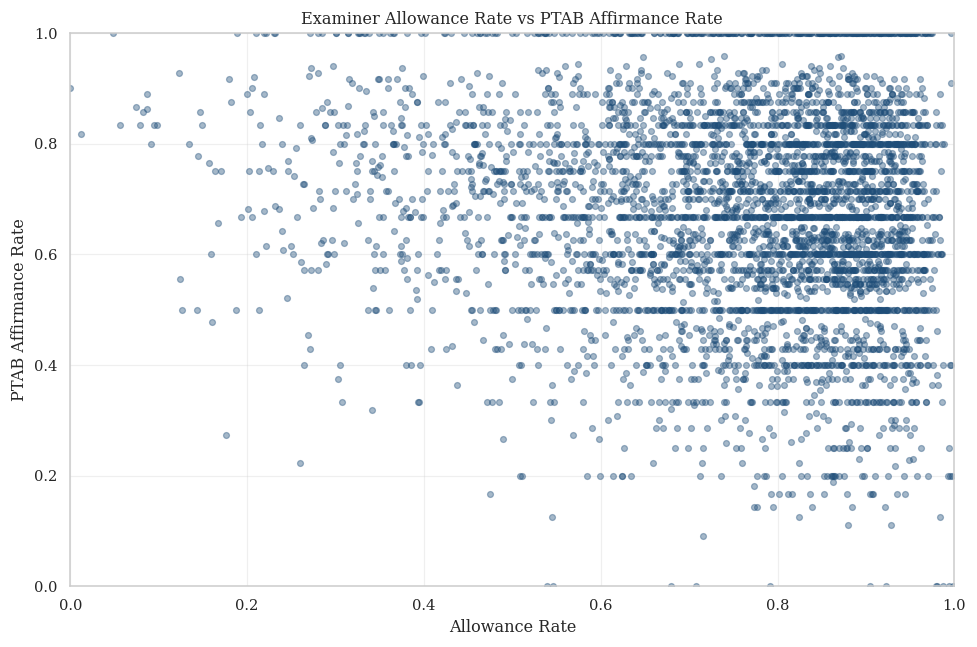

In [0]:
ptab_combined = ptab.merge(examiner_rates[["examiner_name", "allowance_rate"]],
                            on="examiner_name", how="inner")
print(f"Examiners with both metrics: {len(ptab_combined):,}")
print(f"Pearson correlation: {ptab_combined['allowance_rate'].corr(ptab_combined['affirmance_rate']):.3f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(ptab_combined["allowance_rate"], ptab_combined["affirmance_rate"],
           alpha=0.4, s=15, color="#1f4e79")
ax.set_xlabel("Allowance Rate")
ax.set_ylabel("PTAB Affirmance Rate")
ax.set_title("Examiner Allowance Rate vs PTAB Affirmance Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_22")
plt.show()

## Section 5.8 - Temporal Trends

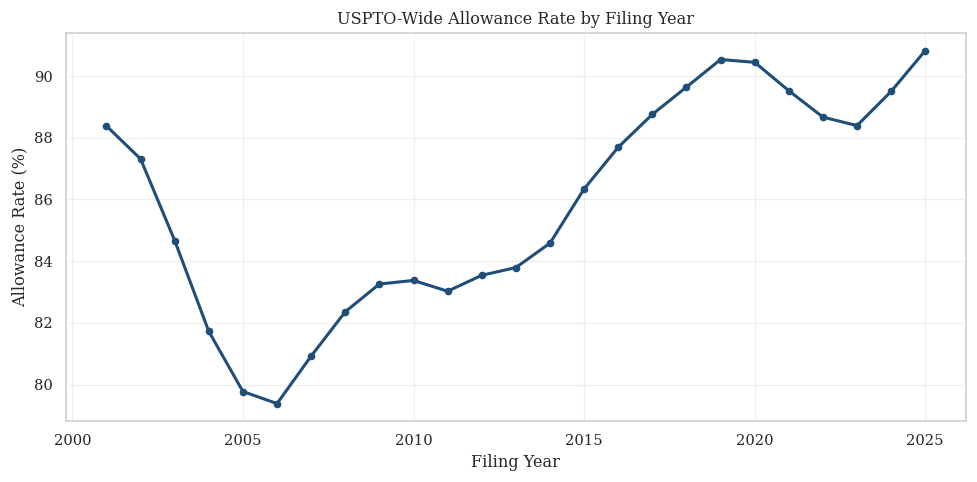

In [0]:
# SCALE FROM 0-100 INSTEAD of 0.8 to 0.9
sql_yearly_allowance = f"""
SELECT
  filing_year,
  SUM(uspto_allowed_count) AS allowed,
  SUM(uspto_rejected_count) AS rejected,
  SUM(uspto_total_apps) AS total
FROM {TBL_ART_UNIT_YEARLY}
WHERE filing_year BETWEEN 2001 AND YEAR(CURRENT_DATE()) - 1
GROUP BY filing_year
ORDER BY filing_year
"""

yearly = q(sql_yearly_allowance)
yearly["allowance_rate"] = yearly["allowed"] / (yearly["allowed"] + yearly["rejected"])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(yearly["filing_year"], yearly["allowance_rate"]*100,
        color="#1f4e79", linewidth=2, marker="o", markersize=4)
ax.set_xlabel("Filing Year")
ax.set_ylabel("Allowance Rate (%)")
ax.set_title("USPTO-Wide Allowance Rate by Filing Year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_23")
plt.show()

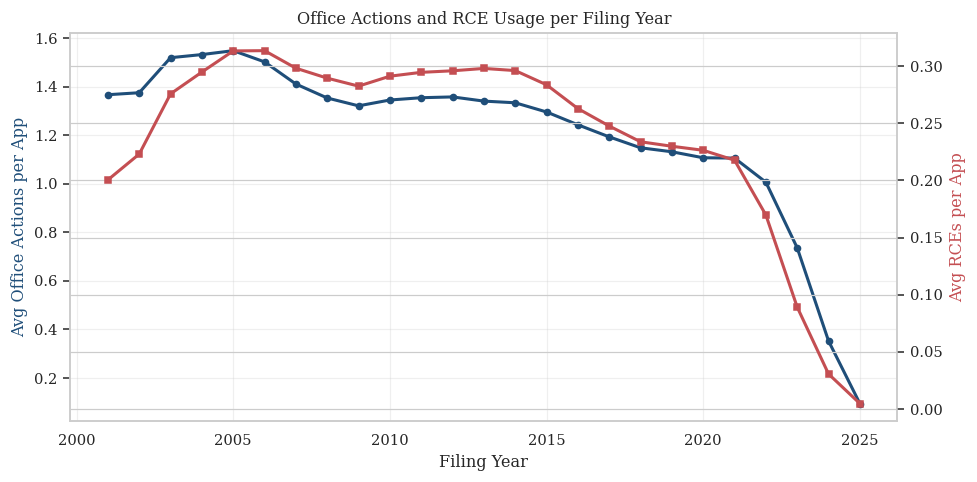

In [0]:
#SEPERATE GRAPH FOR OA AND RCE FOR BETTER CLARITY
sql_oa_rce_trends = f"""
WITH per_app AS (
  SELECT
    a.app_id,
    YEAR(a.filing_date) AS filing_year,
    SUM(CASE WHEN e.event_code IN ('CTNF','CTFR') THEN 1 ELSE 0 END) AS oa_count,
    SUM(CASE WHEN e.event_code = 'RCEX' THEN 1 ELSE 0 END) AS rce_count
  FROM {TBL_APPLICATIONS} a
  LEFT JOIN {TBL_EVENTS} e ON a.app_id = e.app_id
  WHERE a.filing_date IS NOT NULL
    AND YEAR(a.filing_date) BETWEEN 2001 AND YEAR(CURRENT_DATE()) - 1
  GROUP BY a.app_id, YEAR(a.filing_date)
)
SELECT
  filing_year,
  AVG(oa_count) AS avg_oa,
  AVG(rce_count) AS avg_rce
FROM per_app
GROUP BY filing_year
ORDER BY filing_year
"""

oa_rce = q(sql_oa_rce_trends)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()
ax1.plot(oa_rce["filing_year"], oa_rce["avg_oa"], color="#1f4e79", linewidth=2,
         marker="o", markersize=4, label="Avg Office Actions")
ax2.plot(oa_rce["filing_year"], oa_rce["avg_rce"], color="#c44e52", linewidth=2,
         marker="s", markersize=4, label="Avg RCEs")
ax1.set_xlabel("Filing Year")
ax1.set_ylabel("Avg Office Actions per App", color="#1f4e79")
ax2.set_ylabel("Avg RCEs per App", color="#c44e52")
ax1.set_title("Office Actions and RCE Usage per Filing Year")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_24")
plt.show()

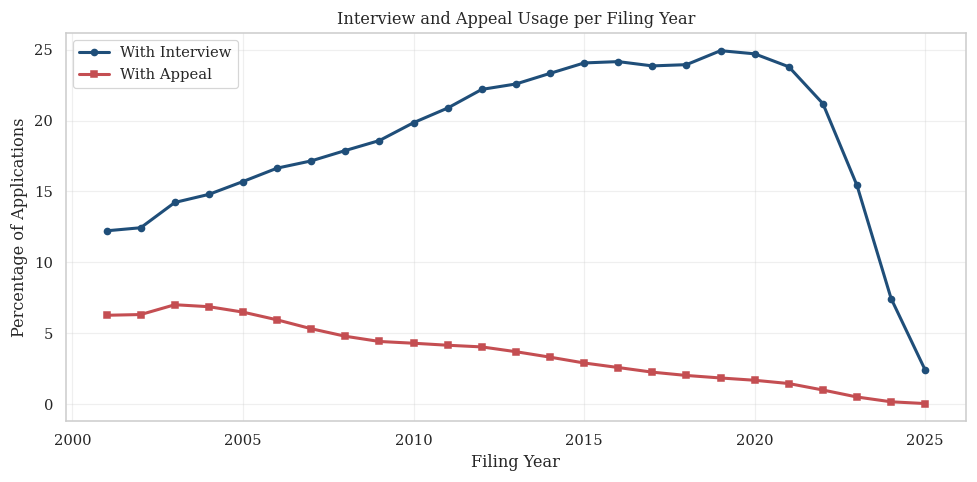

In [0]:
sql_iv_appeal_trends = f"""
WITH apps_iv AS (
  SELECT DISTINCT app_id FROM {TBL_EVENTS}
  WHERE event_code IN ('EXAC','EXAP','EXAT','EXIE','EXEC','EXEP','EXET','EXIA','EXIN',
    'MEXIA','MEXIE','MEXIN','MEXAC','MEXAP','MEXAT','MEXEC','MEXEP','MEXET',
    'MNCIR','NCIR','FAIA','PRTI','MREXN','MRPWP')
),
apps_ap AS (
  SELECT DISTINCT app_id FROM {TBL_EVENTS} WHERE event_code = 'N/AP'
)
SELECT
  YEAR(a.filing_date) AS filing_year,
  COUNT(*) AS total,
  COUNT(iv.app_id) AS with_iv,
  COUNT(ap.app_id) AS with_appeal
FROM {TBL_APPLICATIONS} a
LEFT JOIN apps_iv iv ON a.app_id = iv.app_id
LEFT JOIN apps_ap ap ON a.app_id = ap.app_id
WHERE a.filing_date IS NOT NULL
  AND YEAR(a.filing_date) BETWEEN 2001 AND YEAR(CURRENT_DATE()) - 1
GROUP BY YEAR(a.filing_date)
ORDER BY filing_year
"""

trends = q(sql_iv_appeal_trends)
trends["iv_pct"] = trends["with_iv"]/trends["total"]*100
trends["appeal_pct"] = trends["with_appeal"]/trends["total"]*100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(trends["filing_year"], trends["iv_pct"], color="#1f4e79", linewidth=2,
        marker="o", markersize=4, label="With Interview")
ax.plot(trends["filing_year"], trends["appeal_pct"], color="#c44e52", linewidth=2,
        marker="s", markersize=4, label="With Appeal")
ax.set_xlabel("Filing Year")
ax.set_ylabel("Percentage of Applications")
ax.set_title("Interview and Appeal Usage per Filing Year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "figure_5_25")
plt.show()

## Section 5.9 - Multi-Level Benchmarking

Rows: 17,028


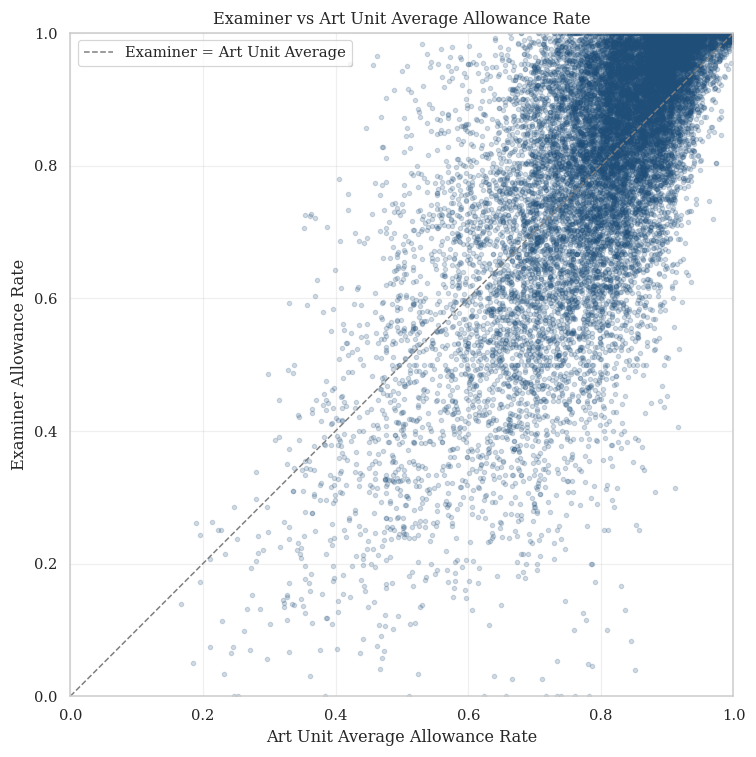

In [0]:
sql_benchmark = f"""
SELECT
  examiner_name,
  group_art_unit,
  examiner_allowance_rate,
  art_unit_avg_allowance_rate,
  total_applications
FROM {TBL_EXAMINER_AU_COMPARISON}
WHERE time_period = 'all'
  AND application_type = 'NONE'
  AND examiner_allowance_rate IS NOT NULL
  AND art_unit_avg_allowance_rate IS NOT NULL
  AND total_applications >= {MIN_DISPOSED}
"""

benchmark = q(sql_benchmark)
print(f"Rows: {len(benchmark):,}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(benchmark["art_unit_avg_allowance_rate"], benchmark["examiner_allowance_rate"],
           alpha=0.2, s=8, color="#1f4e79")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1,
        label="Examiner = Art Unit Average")
ax.set_xlabel("Art Unit Average Allowance Rate")
ax.set_ylabel("Examiner Allowance Rate")
ax.set_title("Examiner vs Art Unit Average Allowance Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
save_fig(fig, "figure_5_26")
plt.show()

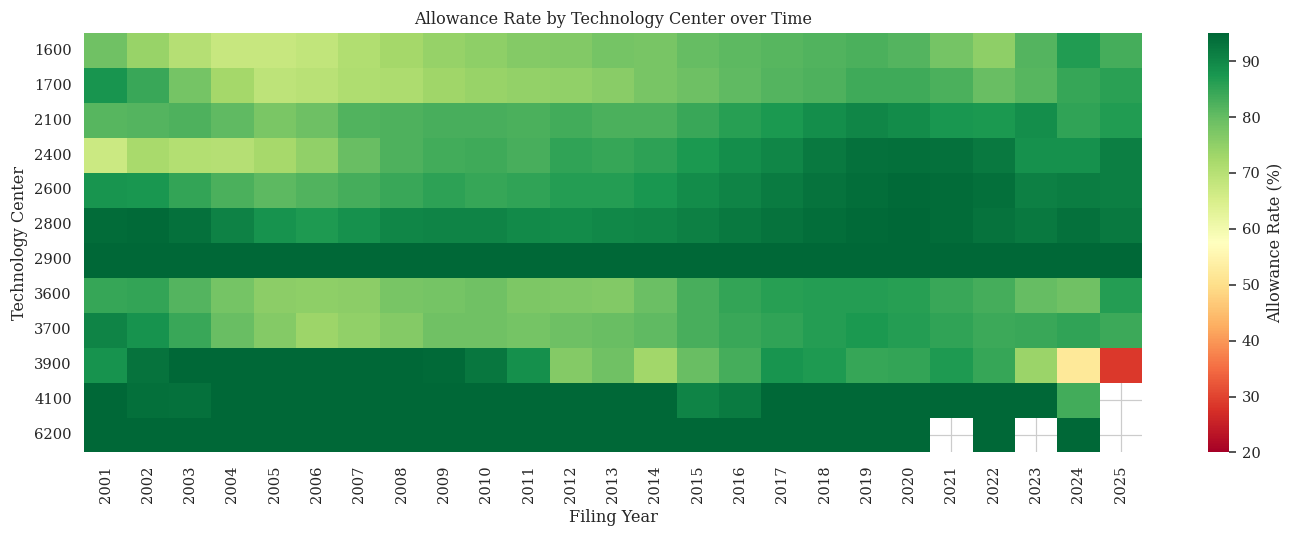

In [0]:
#SCALE FROM 0-100
sql_tc_yearly = f"""
SELECT
  CAST(FLOOR(CAST(group_art_unit AS INT)/100)*100 AS INT) AS tech_center,
  filing_year,
  SUM(uspto_allowed_count) AS allowed,
  SUM(uspto_rejected_count) AS rejected
FROM {TBL_ART_UNIT_YEARLY}
WHERE filing_year BETWEEN 2001 AND YEAR(CURRENT_DATE()) - 1
  AND group_art_unit RLIKE '^[0-9]+$'
GROUP BY FLOOR(CAST(group_art_unit AS INT)/100)*100, filing_year
"""

tc_yearly = q(sql_tc_yearly)
tc_yearly["allowance_rate"] = tc_yearly["allowed"] / (tc_yearly["allowed"] + tc_yearly["rejected"])
heatmap_data = tc_yearly.pivot(index="tech_center", columns="filing_year", values="allowance_rate")
heatmap_data = heatmap_data.dropna(how="all")

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_data*100, ax=ax, cmap="RdYlGn", annot=False,
            cbar_kws={"label": "Allowance Rate (%)"}, vmin=20, vmax=95)
ax.set_xlabel("Filing Year")
ax.set_ylabel("Technology Center")
ax.set_title("Allowance Rate by Technology Center over Time")
plt.tight_layout()
save_fig(fig, "figure_5_27")
plt.show()

## 5.10 Variance Decomposition: Decomposing Sources of Allowance Rate Variation

This section asks: of all the variation we observe in whether an application
is allowed or rejected, how much is attributable to *who the examiner is*
versus the art unit, the filing year, or the application type? We answer this
by running a sequence of nested linear regressions of the binary allowance
outcome on each set of fixed effects and reporting the incremental R-squared
contributed by each factor.

In [0]:
sql_variance_data = f"""
WITH disposition_normalized AS (
  SELECT
    a.app_id,
    a.filing_date,
    a.application_type_code,
    a.examiner_name,
    a.group_art_unit,
    REGEXP_REPLACE(UPPER(TRIM(COALESCE(a.application_status_desc, ''))), '\\\\s+', ' ') AS status_norm,
    SUM(CASE WHEN e.event_code = 'CTFR' THEN 1 ELSE 0 END) AS final_rejection_events
  FROM {TBL_APPLICATIONS} a
  LEFT JOIN {TBL_EVENTS} e
    ON e.app_id = a.app_id AND e.event_code = 'CTFR'
  GROUP BY a.app_id, a.filing_date, a.application_type_code, a.examiner_name,
           a.group_art_unit, a.application_status_desc
),
classified AS (
  SELECT
    app_id,
    examiner_name,
    group_art_unit,
    application_type_code,
    YEAR(filing_date) AS filing_year,
    CASE
      WHEN status_norm IN (
        'PATENTED CASE',
        'PATENT EXPIRED DUE TO NONPAYMENT OF MAINTENANCE FEES UNDER 37 CFR 1.362',
        'ABANDONED -- FAILURE TO PAY ISSUE FEE',
        'NOTICE OF ALLOWANCE MAILED -- APPLICATION RECEIVED IN OFFICE OF PUBLICATIONS',
        'ALLOWED -- NOTICE OF ALLOWANCE NOT YET MAILED'
      ) THEN 1
      WHEN status_norm IN (
        'FINAL REJECTION MAILED',
        'ABANDONED -- AFTER EXAMINER''S ANSWER OR BOARD OF APPEALS DECISION',
        'FINAL REJECTION COUNTED, NOT YET MAILED'
      ) THEN 0
      WHEN status_norm = 'ABANDONED -- FAILURE TO RESPOND TO AN OFFICE ACTION'
        THEN CASE WHEN COALESCE(final_rejection_events, 0) > 0 THEN 0 ELSE NULL END
      ELSE NULL
    END AS allowed
  FROM disposition_normalized
)
SELECT app_id, examiner_name, group_art_unit, application_type_code, filing_year, allowed
FROM classified
WHERE allowed IS NOT NULL
  AND examiner_name IS NOT NULL
  AND TRIM(examiner_name) <> ''
  AND group_art_unit IS NOT NULL
  AND group_art_unit RLIKE '^[0-9]+$'
  AND filing_year IS NOT NULL
  AND application_type_code IS NOT NULL
"""
variance_df = q(sql_variance_data)
variance_df["allowed"] = variance_df["allowed"].astype(float)
variance_df.shape

(7826575, 6)

In [0]:
%pip install pyfixest --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
variance_df = q(sql_variance_data)
variance_df["allowed"] = variance_df["allowed"].astype(float)

In [0]:
import pandas as pd
import numpy as np

df = variance_df.copy()
df["filing_year"]            = df["filing_year"].astype(int)
df["application_type_code"]  = df["application_type_code"].astype(str)
df["group_art_unit"]         = df["group_art_unit"].astype(str)
df["examiner_name"]          = df["examiner_name"].astype(str)
df["allowed"]                = df["allowed"].astype(float)

y = df["allowed"].to_numpy()
y_mean = y.mean()
ss_total = float(np.sum((y - y_mean) ** 2))

def cumulative_r2(group_cols):
    fitted = df.groupby(group_cols, observed=True)["allowed"].transform("mean").to_numpy()
    return float(np.sum((fitted - y_mean) ** 2) / ss_total)

r2_year     = cumulative_r2(["filing_year"])
r2_apptype  = cumulative_r2(["filing_year", "application_type_code"])
r2_artunit  = cumulative_r2(["filing_year", "application_type_code", "group_art_unit"])
r2_examiner = cumulative_r2(["filing_year", "application_type_code", "group_art_unit", "examiner_name"])

incremental = {
    "Filing year":      r2_year,
    "Application type": r2_apptype  - r2_year,
    "Art unit":         r2_artunit  - r2_apptype,
    "Examiner":         r2_examiner - r2_artunit,
    "Unexplained":      1.0 - r2_examiner,
}

decomp = pd.DataFrame({
    "Factor": list(incremental.keys()),
    "Share of variance": list(incremental.values()),
})
decomp["Share of variance (%)"] = (decomp["Share of variance"] * 100).round(2)
decomp

,Factor,Share of variance,Share of variance (%)
0,Filing year,0.009733,0.97
1,Application type,0.015049,1.50
2,Art unit,0.092579,9.26
3,Examiner,0.153300,15.33
4,Unexplained,0.729338,72.93


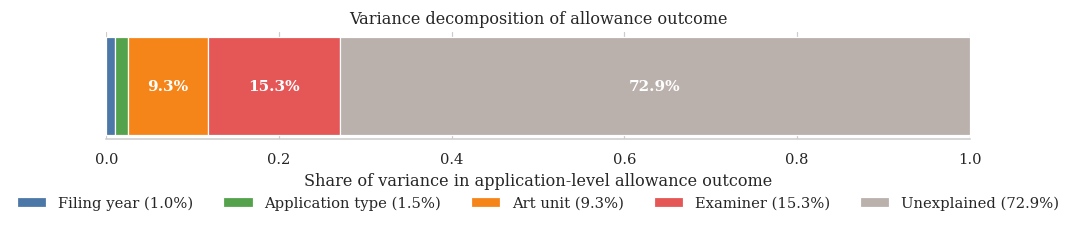


Incremental variance shares:
  Filing year            0.97%
  Application type       1.50%
  Art unit               9.26%
  Examiner              15.33%
  Unexplained           72.93%


In [0]:
fig, ax = plt.subplots(figsize=(10, 2.6))

order = ["Filing year", "Application type", "Art unit", "Examiner", "Unexplained"]
colors = ["#4C78A8", "#54A24B", "#F58518", "#E45756", "#BAB0AC"]

left = 0.0
for factor, color in zip(order, colors):
    width = float(decomp.loc[decomp["Factor"] == factor, "Share of variance"].iloc[0])
    ax.barh(0, width, left=left, color=color, edgecolor="white", label=f"{factor} ({width*100:.1f}%)")
    if width > 0.02:
        ax.text(left + width / 2, 0, f"{width*100:.1f}%", va="center", ha="center",
                color="white", fontsize=10, fontweight="bold")
    left += width

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Share of variance in application-level allowance outcome")
ax.set_title("Variance decomposition of allowance outcome")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.4), ncol=5, frameon=False)
sns.despine(left=True, bottom=False)
plt.tight_layout()
save_fig(fig, "figure_5_28")
plt.show()

print("\nIncremental variance shares:")
for f in order:
    v = float(decomp.loc[decomp["Factor"] == f, "Share of variance"].iloc[0])
    print(f"  {f:<20s} {v*100:6.2f}%")